#Análisis de variables

In [11]:
pip install matplotlib-scalebar

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.api import GLM, families
import geopandas as gpd
import pandas as pd
from matplotlib_scalebar.scalebar import ScaleBar

In [2]:
#variables
variables = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/Barrios_var.gpkg", layer="variables")
variables.head()

,nombre_bar,nombre_com,Shape_Leng,Shape_Area,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean,Porc_Artificial,Porc_Qca,Porc_TPu,geometry
0,Aguas Frias,ALTAVISTA,32888.553485,1.308501e+07,27,13.085013,2.063429,3.472526,1.156317,0.332990,29.564836,5.118618,2.471720,0.000000,"MULTIPOLYGON (((4710927.69 2248217.723, 471092..."
1,Aldea Pablo VI,POPULAR,1548.983811,5.560887e+04,3,0.055609,53.948225,0.014758,0.128480,8.706006,19.185280,64.712141,0.000000,100.000000,"MULTIPOLYGON (((4718950.025 2253647.826, 47189..."
2,Alejandro Echavarría,BUENOS AIRES,3873.259719,3.600769e+05,15,0.360077,41.657774,0.095558,0.642398,6.722609,11.555980,62.817569,88.785759,11.039618,"MULTIPOLYGON (((4718344.177 2248210.468, 47183..."
3,Alejandría,EL POBLADO,2783.340991,4.314227e+05,8,0.431423,18.543298,0.114492,0.342612,2.992463,10.526186,46.877115,100.000000,0.000000,"MULTIPOLYGON (((4715894.965 2243436.368, 47158..."
4,Alfonso López,CASTILLA,3360.868167,3.679919e+05,2,0.367992,5.434902,0.097658,0.085653,0.877069,9.505469,73.895347,88.106810,0.000000,"MULTIPOLYGON (((4715035.462 2253564.342, 47150..."


In [3]:
gdf = variables

In [4]:
gdf[[ "nombre_bar",
        "Area_km2",
        "Porc_Artificial",
        "Porc_Qca",
        "Porc_TPu",
        "Pend_mean" ]].round(2)

,nombre_bar,Area_km2,Porc_Artificial,Porc_Qca,Porc_TPu,Pend_mean
0,Aguas Frias,13.09,5.12,2.47,0.00,29.56
1,Aldea Pablo VI,0.06,64.71,0.00,100.00,19.19
2,Alejandro Echavarría,0.36,62.82,88.79,11.04,11.56
3,Alejandría,0.43,46.88,100.00,0.00,10.53
4,Alfonso López,0.37,73.90,88.11,0.00,9.51
...,...,...,...,...,...,...
343,Volcana Guayabal,9.28,3.32,0.00,0.00,33.81
344,Yarumalito,14.83,2.36,0.02,0.00,32.26
345,Yolombo,4.64,4.69,4.34,0.00,21.16
346,Área de Expansión Pajarito,2.40,29.74,100.00,0.00,18.23


#Matriz espacial

In [5]:
from libpysal import weights

w_queen = weights.Queen.from_dataframe(gdf, ids=gdf["nombre_bar"])

w_queen.transform = "r"

w_queen

('WARNING: ', 'Alejandro Echavarría', ' is an island (no neighbors)')


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: Alejandro Echavarría.
  W.__init__(self, neighbors, ids=ids, **kw)


In [6]:
w_queen.neighbors['Santa Cruz']

['Palermo',
 'Héctor Abad Gómez',
 'San Isidro',
 'La Rosa',
 'Tricentenario',
 'Villa Niza',
 'Villa del Socorro',
 'Moscú No. 1',
 'Belalcázar']

In [7]:
w_queen.cardinalities['Santa Cruz']

9

In [8]:
queen_vec = pd.Series(w_queen.cardinalities)
queen_vec

,0
Aguas Frias,15
Aldea Pablo VI,4
Alejandro Echavarría,0
Alejandría,6
Alfonso López,7
...,...
Volcana Guayabal,3
Yarumalito,4
Yolombo,5
Área de Expansión Pajarito,10


In [9]:
gdf_idx = gdf.set_index("nombre_bar")

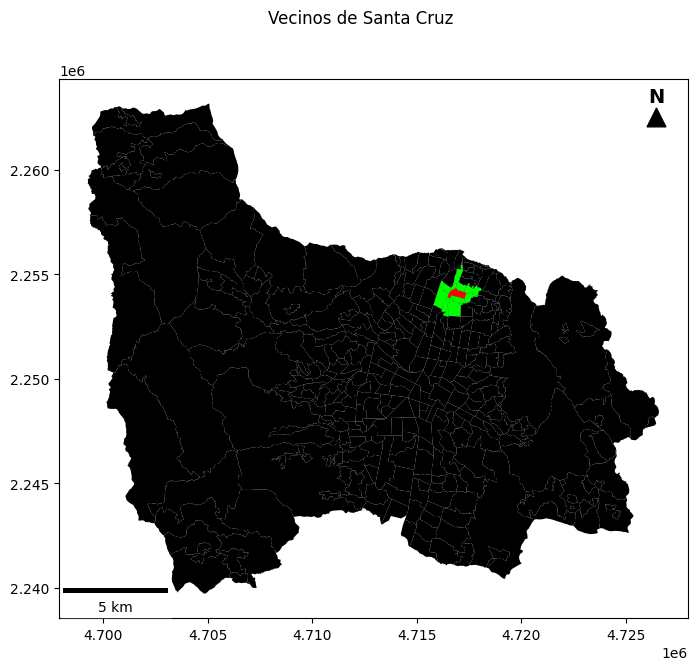

In [14]:
f, ax = plt.subplots(1, figsize=(10, 7))

gdf_idx.plot(ax=ax, facecolor='k', linewidth=5)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)

focus = gdf_idx.loc[['Santa Cruz'], ['geometry']]

focus.plot(facecolor='red', alpha=1, linewidth=0, ax=ax)

neighbors_list = list(w_queen['Santa Cruz'])

neis = gdf_idx.loc[neighbors_list, :]
neis.plot(ax=ax, facecolor='lime', linewidth=0)

f.suptitle("Vecinos de Santa Cruz")

plt.show()

In [15]:
knn5 = weights.KNN.from_dataframe(gdf_idx, k=5)
knn5['Santa Cruz']
knn5.transform = "r"

In [16]:
knn5_vec = pd.Series(knn5.cardinalities)
knn5_vec

,0
Aguas Frias,5
Aldea Pablo VI,5
Alejandro Echavarría,5
Alejandría,5
Alfonso López,5
...,...
Volcana Guayabal,5
Yarumalito,5
Yolombo,5
Área de Expansión Pajarito,5


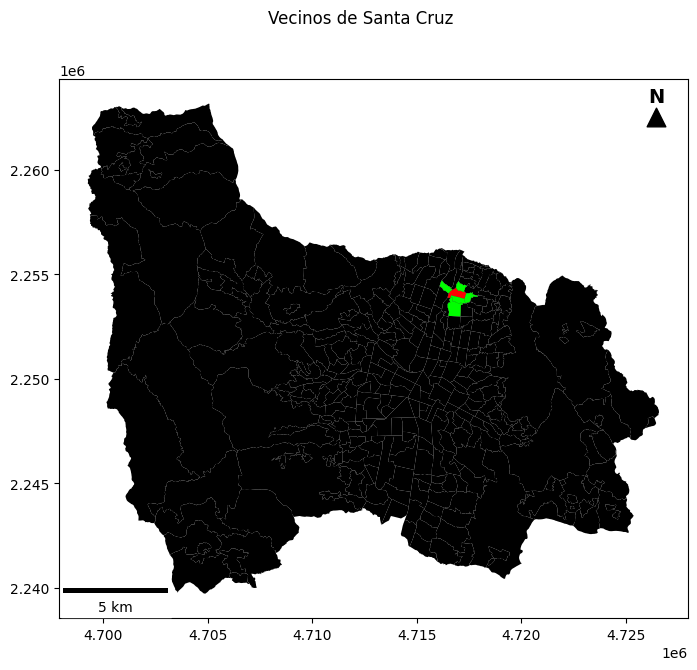

In [17]:
f, ax = plt.subplots(1, figsize=(10, 7))

gdf_idx.plot(ax=ax, facecolor='k', linewidth=5)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)

focus = gdf_idx.loc[['Santa Cruz'], ['geometry']]

focus.plot(facecolor='red', alpha=1, linewidth=0, ax=ax)

neighbors_list = list(knn5['Santa Cruz'])

neis = gdf_idx.loc[neighbors_list, :]
neis.plot(ax=ax, facecolor='lime', linewidth=0)

f.suptitle("Vecinos de Santa Cruz")

plt.show()

In [18]:
w_dist1km = weights.DistanceBand.from_dataframe(gdf_idx, 1000)
w_dist1km['Santa Cruz']
w_dist1km.transform = "r"

('WARNING: ', 'Altavista Sector Central', ' is an island (no neighbors)')
('WARNING: ', 'Barro Blanco', ' is an island (no neighbors)')
('WARNING: ', 'Boqueron', ' is an island (no neighbors)')
('WARNING: ', 'El Astillero', ' is an island (no neighbors)')
('WARNING: ', 'El Carmelo', ' is an island (no neighbors)')
('WARNING: ', 'El Llano SE', ' is an island (no neighbors)')
('WARNING: ', 'El Salado (San Antonio)', ' is an island (no neighbors)')
('WARNING: ', 'La Florida (San Antonio)', ' is an island (no neighbors)')
('WARNING: ', 'La Frisola', ' is an island (no neighbors)')
('WARNING: ', 'La Loma', ' is an island (no neighbors)')
('WARNING: ', 'La Oculta', ' is an island (no neighbors)')
('WARNING: ', 'La Palma-El Patio', ' is an island (no neighbors)')
('WARNING: ', 'La Suiza', ' is an island (no neighbors)')
('WARNING: ', 'La Urquita', ' is an island (no neighbors)')
('WARNING: ', 'La Verde', ' is an island (no neighbors)')
('WARNING: ', 'Las Palmas (Santa Elena)', ' is an island 

/usr/local/lib/python3.12/dist-packages/libpysal/weights/util.py:819: UserWarning: The weights matrix is not fully connected: 
 There are 50 disconnected components.
 There are 34 islands with ids: Altavista Sector Central, Barro Blanco, Boqueron, El Astillero, El Carmelo, El Llano SE, El Salado (San Antonio), La Florida (San Antonio), La Frisola, La Loma, La Oculta, La Palma-El Patio, La Suiza, La Urquita, La Verde, Las Palmas (Santa Elena), Media Luna, Pajarito (San Cristobal), Palmitas Sector Central, Piedras Blancas, Potrera Miserenga, San Jose Del Manzanillo, San José de la Montaña, Suburbano Barro Blanco, Suburbano Chacaltaya, Suburbano La Palma-El Patio, Suburbano Palmitas, Suburbano Potrera Miserenga, Suburbano Travesias, Suburbano Urquita, Suburbano el Tesoro, Volcana Guayabal, Yarumalito, Yolombo.
  w = W(neighbors, weights, ids, **kwargs)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:855: UserWarning: The weights matrix is not fully connected: 
 There 

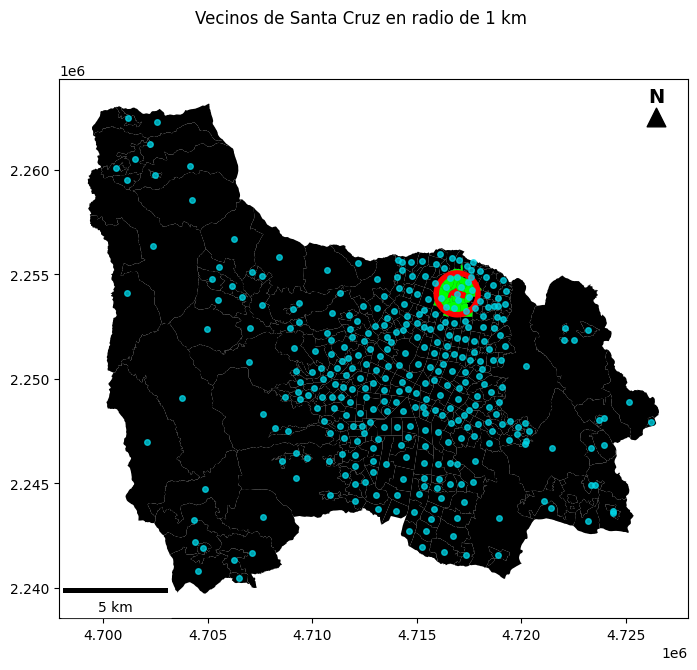

In [19]:
f, ax = plt.subplots(1, figsize=(10, 7))

gdf_idx.plot(ax=ax, facecolor='k', linewidth=0.1)

focus = gdf_idx.loc[['Santa Cruz'], ['geometry']]

focus.plot(facecolor='red', alpha=1, linewidth=0, ax=ax)

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)

neighbors_list = list(w_dist1km['Santa Cruz'])

neis = gdf_idx.loc[neighbors_list, :]
neis.plot(ax=ax, facecolor='lime', linewidth=0)

buf = focus.centroid.buffer(1000)
buf.plot(edgecolor='red', facecolor='none', ax=ax, linewidth=4)

pts = np.array([(pt.x, pt.y) for pt in gdf_idx.centroid])
ax.plot(pts[:, 0], pts[:, 1], color='#00d8ea',
        linewidth=0, alpha=0.75, marker='o', markersize=4)

f.suptitle("Vecinos de Santa Cruz en radio de 1 km")

plt.show()

#Rezago espacial

####Con matriz de contiguidad

In [20]:
gdf_idx['wc_Densidad'] = weights.lag_spatial(w_queen, gdf_idx['Densidad'])
gdf_idx['wc_Porc_Artificial'] = weights.lag_spatial(w_queen, gdf_idx['Porc_Artificial'])
gdf_idx['wc_Porc_Qca'] = weights.lag_spatial(w_queen, gdf_idx['Porc_Qca'])
gdf_idx['wc_Porc_TPu'] = weights.lag_spatial(w_queen, gdf_idx['Porc_TPu'])
gdf_idx['wc_Pend_mean'] = weights.lag_spatial(w_queen, gdf_idx['Pend_mean'])
gdf_idx['wc_Movimientos'] = weights.lag_spatial(w_queen, gdf_idx['Movimientos'])

In [21]:
gdf_idx[['Movimientos', 'wc_Movimientos']].head()

,Movimientos,wc_Movimientos
nombre_bar,,
Aguas Frias,27,9.200000
Aldea Pablo VI,3,12.500000
Alejandro Echavarría,15,0.000000
Alejandría,8,4.833333
Alfonso López,2,2.428571


####Con Matriz de distancia

In [22]:
gdf_idx['wd_Densidad'] = weights.lag_spatial(w_dist1km, gdf_idx['Densidad'])
gdf_idx['wd_Porc_Artificial'] = weights.lag_spatial(w_dist1km, gdf_idx['Porc_Artificial'])
gdf_idx['wd_Porc_Qca'] = weights.lag_spatial(w_dist1km, gdf_idx['Porc_Qca'])
gdf_idx['wd_Porc_TPu'] = weights.lag_spatial(w_dist1km, gdf_idx['Porc_TPu'])
gdf_idx['wd_Pend_mean'] = weights.lag_spatial(w_dist1km, gdf_idx['Pend_mean'])
gdf_idx['wd_Movimientos'] = weights.lag_spatial(w_dist1km, gdf_idx['Movimientos'])

In [23]:
gdf_idx[['Movimientos', 'wd_Movimientos']].head()

,Movimientos,wd_Movimientos
nombre_bar,,
Aguas Frias,27,0.000000
Aldea Pablo VI,3,19.100000
Alejandro Echavarría,15,18.666667
Alejandría,8,4.333333
Alfonso López,2,2.400000


####Con los 5 vecinos más cercanos

In [24]:
gdf_idx['w_Densidad'] = weights.lag_spatial(knn5, gdf_idx['Densidad'])
gdf_idx['w_Porc_Artificial'] = weights.lag_spatial(knn5, gdf_idx['Porc_Artificial'])
gdf_idx['w_Porc_Qca'] = weights.lag_spatial(knn5, gdf_idx['Porc_Qca'])
gdf_idx['w_Porc_TPu'] = weights.lag_spatial(knn5, gdf_idx['Porc_TPu'])
gdf_idx['w_Pend_mean'] = weights.lag_spatial(knn5, gdf_idx['Pend_mean'])
gdf_idx['w_Movimientos'] = weights.lag_spatial(knn5, gdf_idx['Movimientos'])

In [25]:
knn5.neighbors['Alejandro Echavarría']

[np.str_('Los Cerros El Vergel'),
 np.str_('Miraflores'),
 np.str_('La Libertad'),
 np.str_('Villatina'),
 np.str_('El Pinal')]

In [26]:
vecinos = knn5.neighbors["Alejandro Echavarría"]

gdf[gdf["nombre_bar"].isin(vecinos)][
    ["nombre_bar", "Movimientos"]
].sort_values("Movimientos", ascending=False)

,nombre_bar,Movimientos
342,Villatina,47
92,El Pinal,28
157,La Libertad,25
215,Miraflores,5
199,Los Cerros El Vergel,3


In [27]:
gdf_idx[['Movimientos', 'w_Movimientos']].head()

,Movimientos,w_Movimientos
nombre_bar,,
Aguas Frias,27,8.2
Aldea Pablo VI,3,14.0
Alejandro Echavarría,15,21.6
Alejandría,8,4.8
Alfonso López,2,1.6


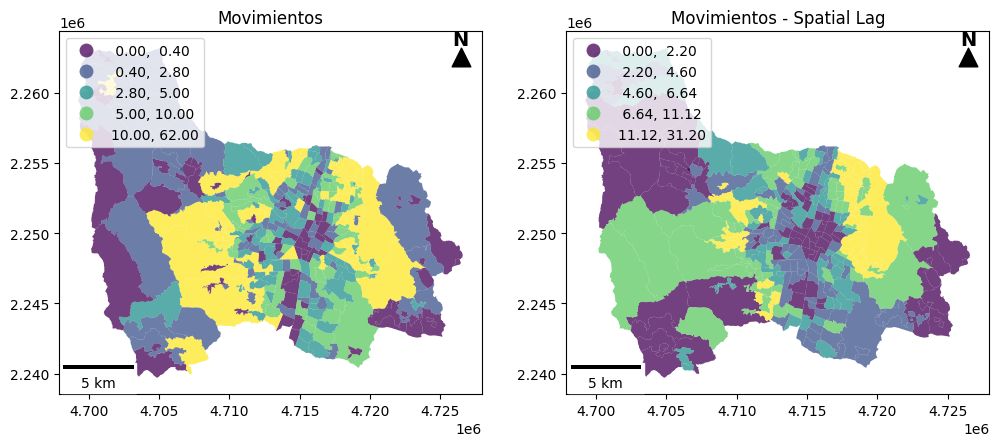

In [29]:
f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs

gdf_idx.plot(column='Movimientos', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax1)
scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax1.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax1.transAxes,
    clip_on=False,
    zorder=10)

ax1.text(
    0.95,
    0.95,
    "N",
    transform=ax1.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax1.add_artist(scalebar)
ax1.set_title("Movimientos")

gdf_idx.plot(column='w_Movimientos', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax2)
scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax2.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax2.transAxes,
    clip_on=False,
    zorder=10)

ax2.text(
    0.95,
    0.95,
    "N",
    transform=ax2.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax2.add_artist(scalebar)
ax2.set_title("Movimientos - Spatial Lag")
plt.show()

##Moran

In [30]:
gdf_idx['Movimientos_std'] = (gdf_idx['Movimientos'] - gdf_idx['Movimientos'].mean()) / gdf_idx['Movimientos'].std()
gdf_idx['w_Movimientos_std'] = weights.lag_spatial(knn5, gdf_idx['Movimientos_std'])

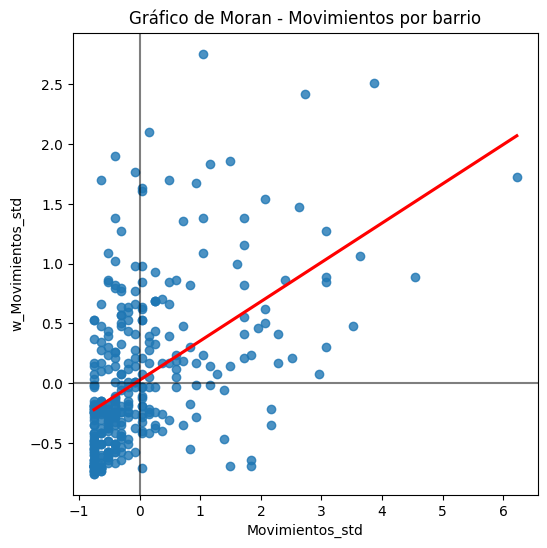

In [32]:
import seaborn as sbn
gdf_idx['Movimientos_lag_std'] = ( gdf_idx['w_Movimientos_std'] - gdf_idx['w_Movimientos_std'].mean() )/ gdf_idx['w_Movimientos_std'].std()

f, ax = plt.subplots(1, figsize=(6, 6))
sbn.regplot(x='Movimientos_std', y='w_Movimientos_std',ci=None, data=gdf_idx, line_kws={'color':'r'})

ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)
ax.set_title('Gráfico de Moran - Movimientos por barrio')
plt.show()

In [33]:
from esda.moran import Moran

mi1 = Moran(gdf_idx['Movimientos'], knn5)
mi1.I

np.float64(0.3281662708691373)

In [34]:
mi1.p_sim

np.float64(0.001)

In [35]:
miq = Moran(gdf_idx['Movimientos'], w_queen)
miq.I

np.float64(0.3218953923098065)

In [36]:
miq.p_sim

np.float64(0.001)

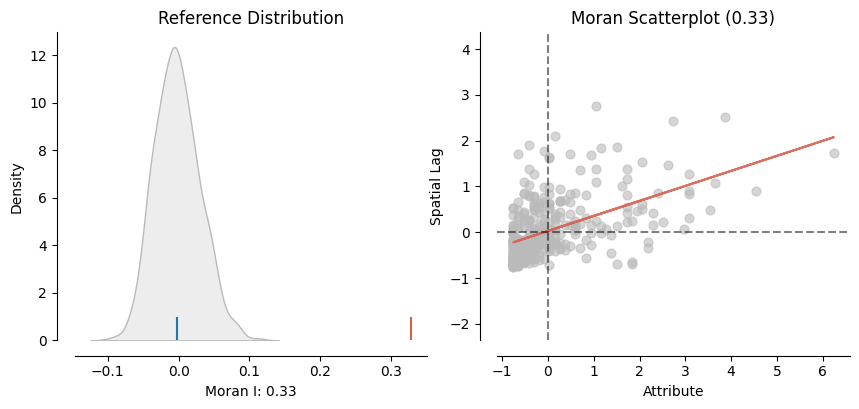

In [43]:
from pysal.viz import splot
from splot.esda import plot_moran
plot_moran(mi1);

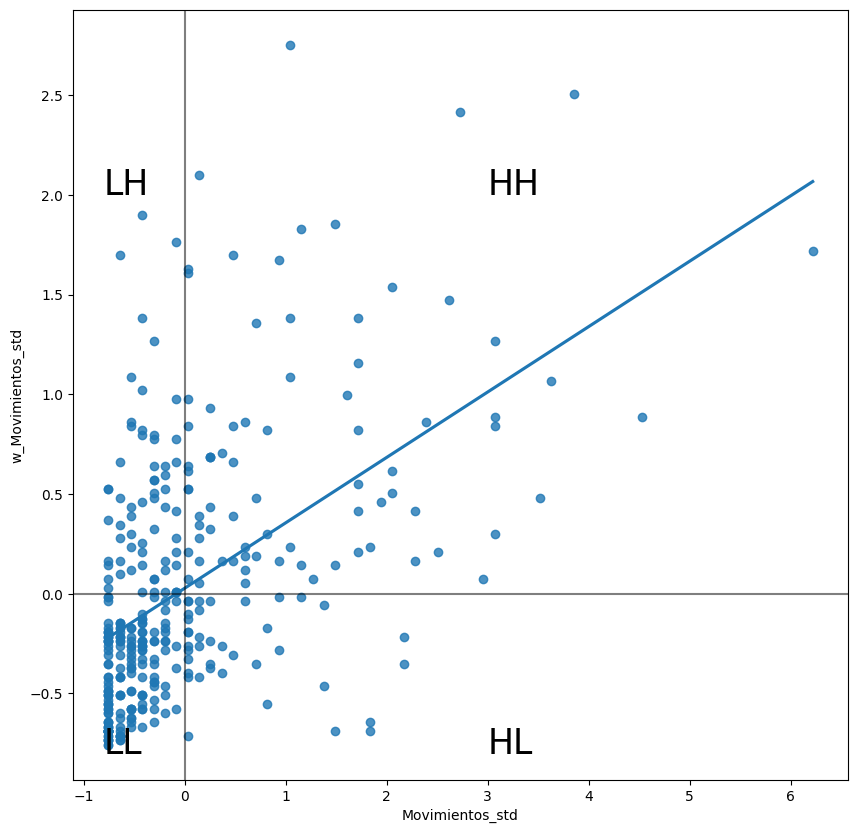

In [ ]:
f, ax = plt.subplots(1, figsize=(10, 10))

sbn.regplot(x='Movimientos_std', y='w_Movimientos_std', data=gdf_idx, ci=None)

plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
plt.text(3, 2, "HH", fontsize=25)
plt.text(3, -0.8, "HL", fontsize=25)
plt.text(-0.8, 2, "LH", fontsize=25)
plt.text(-0.8, -0.8, "LL", fontsize=25)

plt.show()

##LISA

In [50]:
from esda.moran import Moran_Local
lisa1 = Moran_Local(gdf_idx['Movimientos'], knn5)

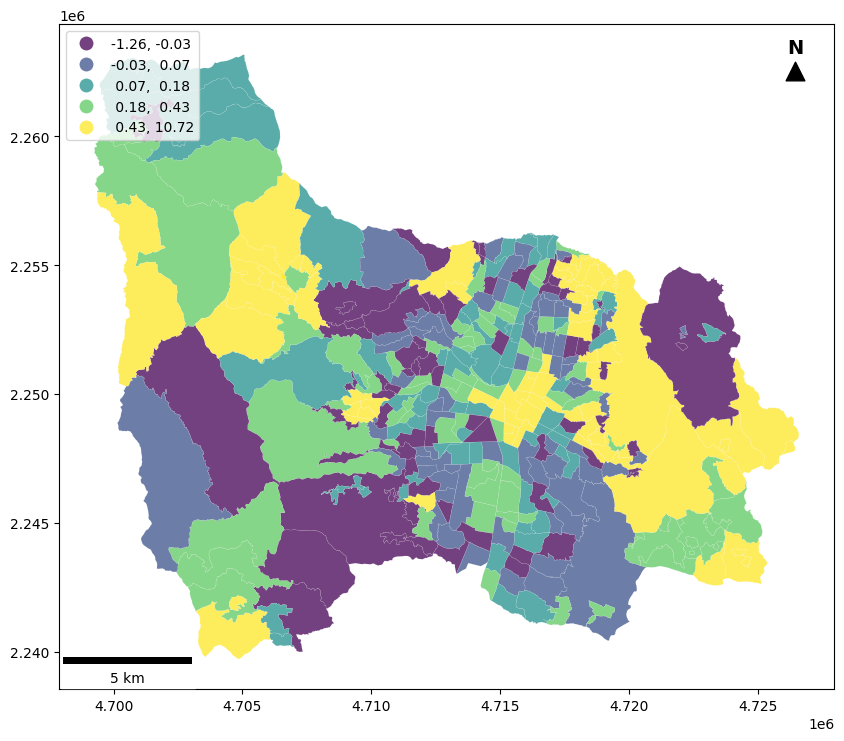

In [51]:
f, ax = plt.subplots(1, figsize=(10,10))

gdf_idx['Is'] = lisa1.Is

gdf_idx.plot(column='Is', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True,ax=ax);

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)

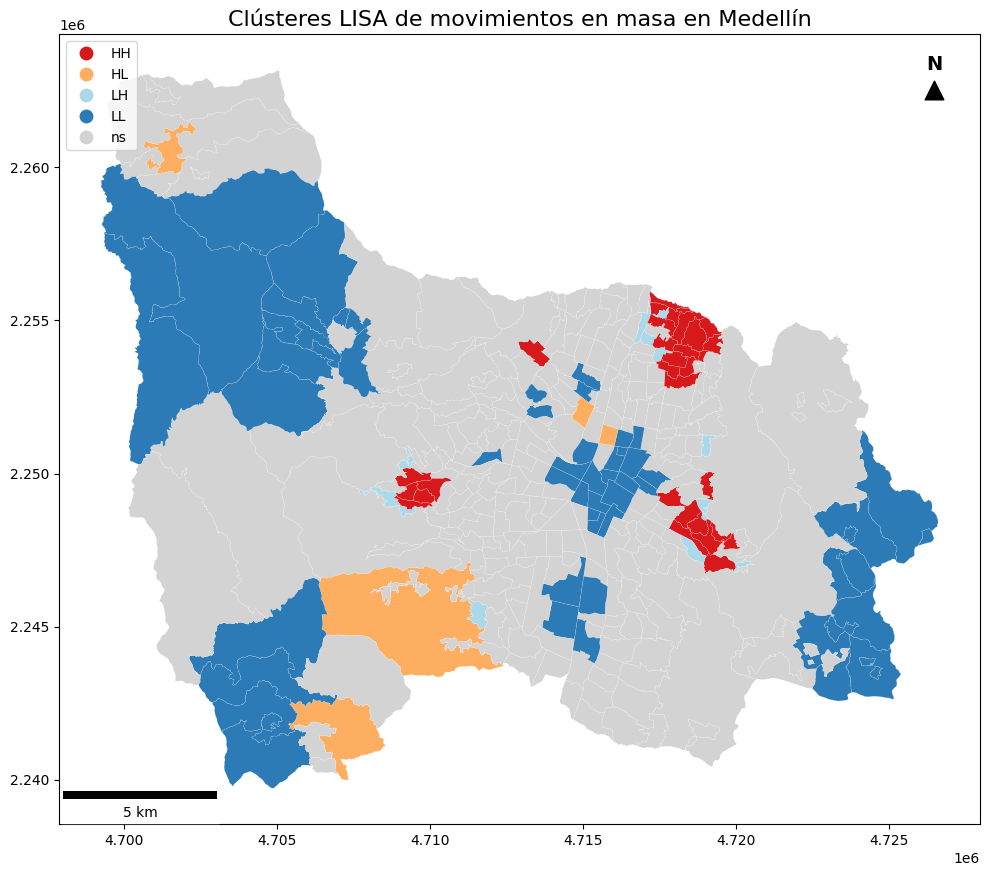

In [56]:
from splot.esda import lisa_cluster

fig, ax = plt.subplots(figsize=(10, 10))

# Dibujar sobre ese eje
lisa_cluster(lisa1, gdf_idx, ax=ax)

scalebar = ScaleBar(dx=1, units="m", dimension="si-length", fixed_value=5, fixed_units="km", location="lower left")

ax.scatter( 0.95, 0.93, marker="^", s=180, color="black", transform=ax.transAxes, clip_on=False, zorder=10)

ax.text(0.95, 0.95, "N", transform=ax.transAxes, ha="center", va="bottom", fontsize=14, fontweight="bold")

ax.add_artist(scalebar)
ax.set_title("Clústeres LISA de movimientos en masa en Medellín", fontsize=16)
ax.set_axis_on()

plt.tight_layout()
plt.show()

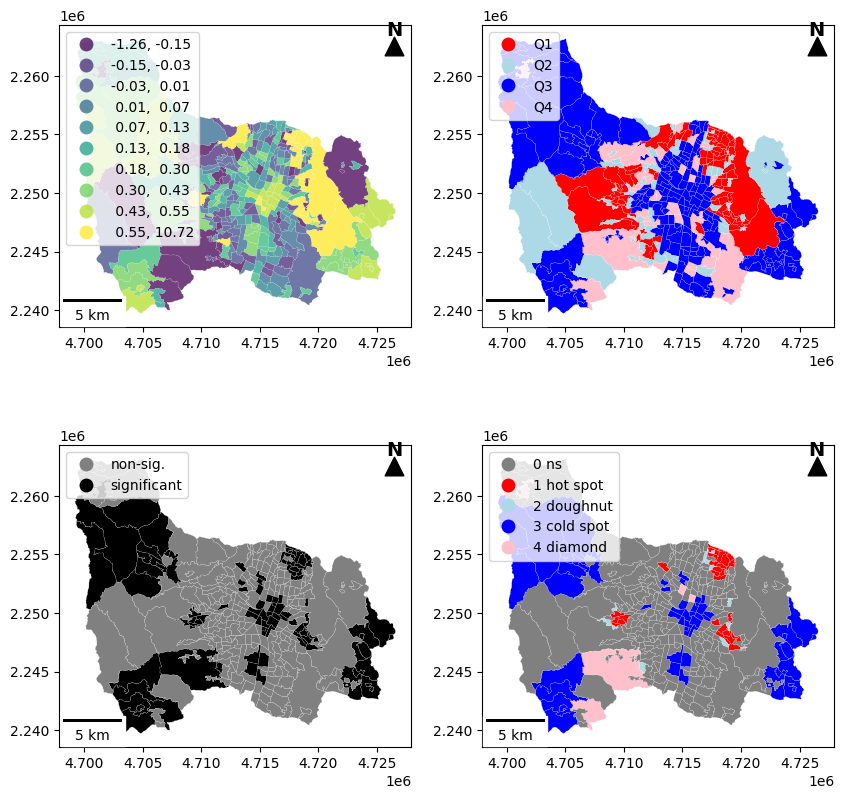

In [67]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

f, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
axs = axs.flatten()

# Is
ax = axs[0]
gdf_idx.plot(column='Is', cmap='viridis', scheme='quantiles', k=10, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True, ax=ax)
scalebar = ScaleBar(dx=1, units="m", dimension="si-length", fixed_value=5, fixed_units="km", location="lower left")
ax.scatter( 0.95, 0.93, marker="^", s=180, color="black", transform=ax.transAxes, clip_on=False, zorder=10)
ax.text(0.95, 0.95, "N", transform=ax.transAxes, ha="center", va="bottom", fontsize=14, fontweight="bold")
ax.add_artist(scalebar)
ax.set_aspect('equal')


# Cuadrantes
ax = axs[1]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels = [q_labels[i-1] for i in lisa1.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', 'pink'])
gdf_idx.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
scalebar = ScaleBar(dx=1, units="m", dimension="si-length", fixed_value=5, fixed_units="km", location="lower left")
ax.scatter( 0.95, 0.93, marker="^", s=180, color="black", transform=ax.transAxes, clip_on=False, zorder=10)
ax.text(0.95, 0.95, "N", transform=ax.transAxes, ha="center", va="bottom", fontsize=14, fontweight="bold")
ax.add_artist(scalebar)
ax.set_aspect('equal')


# Significancia
ax = axs[2]
sig = 1 * (lisa1.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels = ['non-sig.', 'significant']
labels = [labels[i] for i in sig]
gdf_idx.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
scalebar = ScaleBar(dx=1, units="m", dimension="si-length", fixed_value=5, fixed_units="km", location="lower left")
ax.scatter( 0.95, 0.93, marker="^", s=180, color="black", transform=ax.transAxes, clip_on=False, zorder=10)
ax.text(0.95, 0.95, "N", transform=ax.transAxes, ha="center", va="bottom", fontsize=14, fontweight="bold")
ax.add_artist(scalebar)
ax.set_aspect('equal')


# Clústeres
ax = axs[3]
hotspot = 1 * (sig * lisa1.q==1)
coldspot = 3 * (sig * lisa1.q==3)
doughnut = 2 * (sig * lisa1.q==2)
diamond = 4 * (sig * lisa1.q==4)
spots = hotspot + coldspot + doughnut + diamond
spot_labels = [ '0 ns', '1 hot spot', '2 doughnut', '3 cold spot', '4 diamond']
labels = [spot_labels[i] for i in spots]
hmap = ListedColormap([ 'grey', 'red', 'lightblue', 'blue', 'pink'])
gdf.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
scalebar = ScaleBar(dx=1, units="m", dimension="si-length", fixed_value=5, fixed_units="km", location="lower left")
ax.scatter( 0.95, 0.93, marker="^", s=180, color="black", transform=axs[3].transAxes, clip_on=False, zorder=10)
ax.text(0.95, 0.95, "N", transform=ax.transAxes, ha="center", va="bottom", fontsize=14, fontweight="bold")
ax.add_artist(scalebar)
ax.set_aspect('equal')


plt.show()

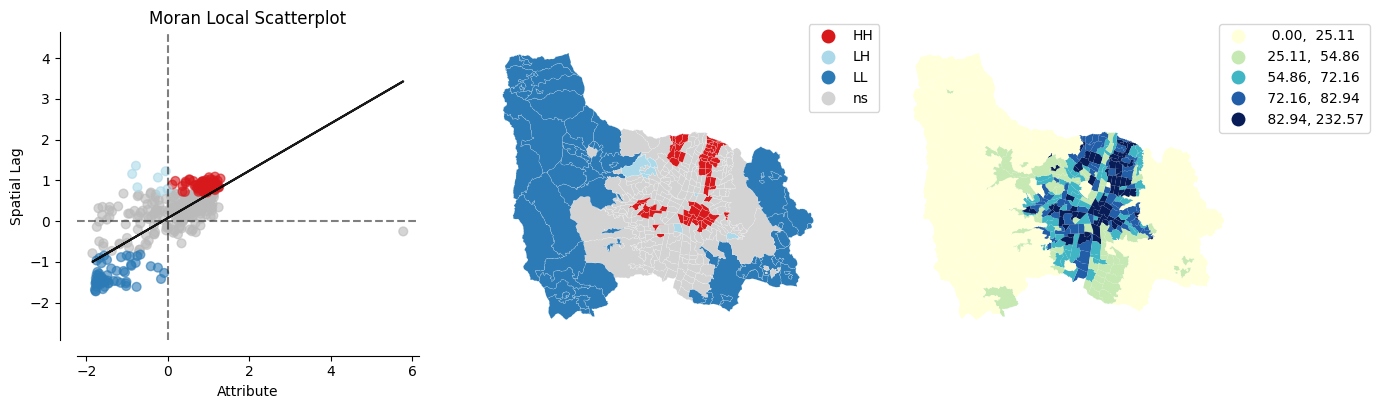

In [ ]:
from splot.esda import plot_local_autocorrelation
lisa_art = Moran_Local(gdf_idx["Porc_Artificial"], knn5)
plot_local_autocorrelation(lisa_art, gdf_idx, 'Porc_Artificial');

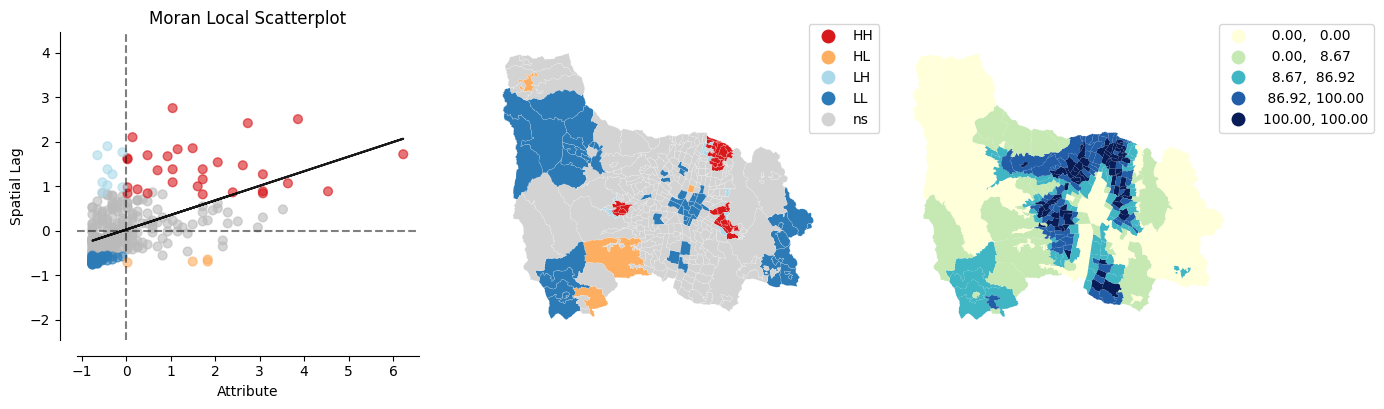

In [ ]:
from splot.esda import plot_local_autocorrelation
lisa_Qca = Moran_Local(gdf_idx["Porc_Qca"], knn5)
plot_local_autocorrelation(lisa_Qca, gdf_idx, 'Porc_Qca');

/usr/local/lib/python3.12/dist-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 2.
  self.bins = quantile(y, k=k)


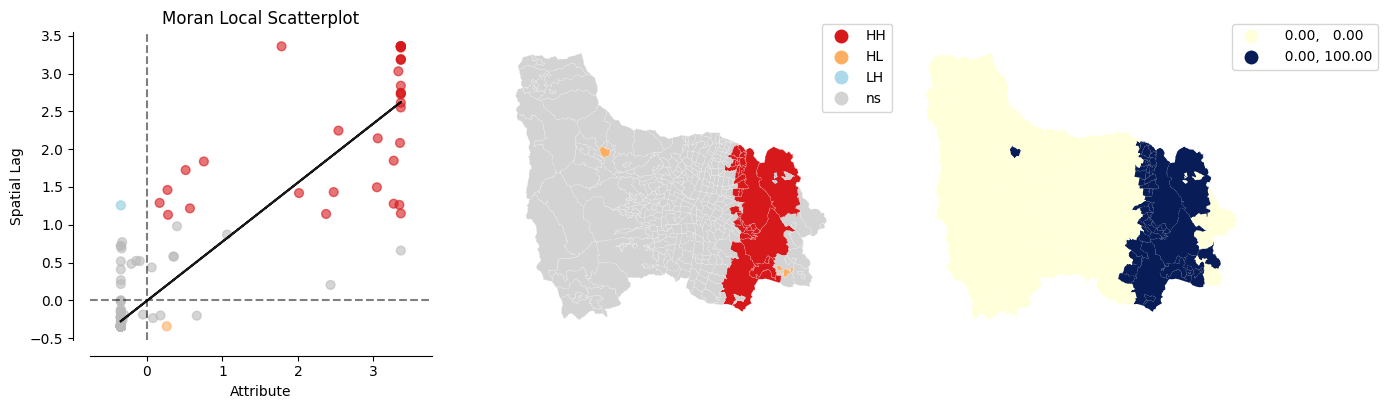

In [ ]:
from splot.esda import plot_local_autocorrelation
lisa_TPu = Moran_Local(gdf_idx["Porc_TPu"], knn5)
plot_local_autocorrelation(lisa_TPu, gdf_idx, 'Porc_TPu');

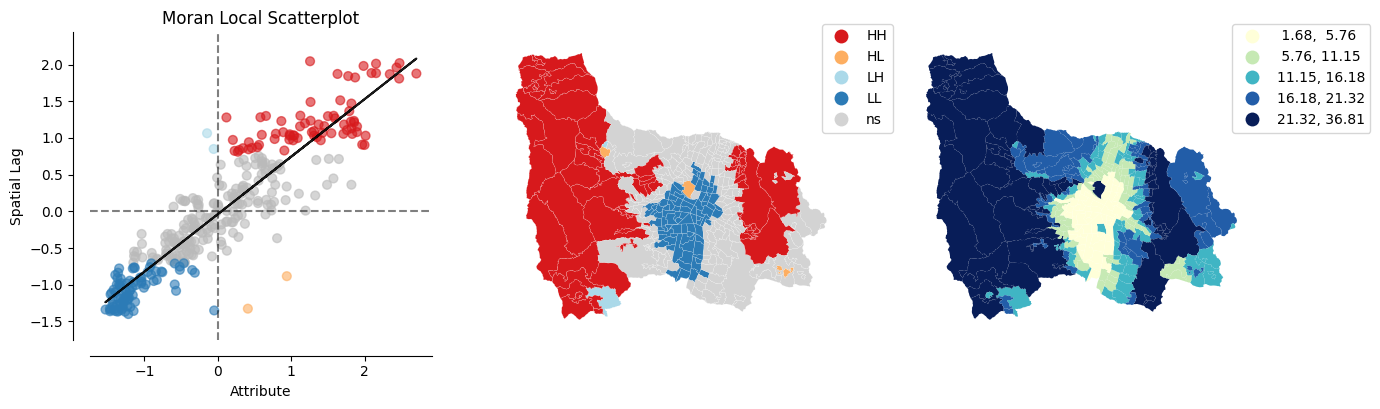

In [ ]:
from splot.esda import plot_local_autocorrelation
lisa_pend = Moran_Local(gdf_idx["Pend_mean"], knn5)
plot_local_autocorrelation(lisa_pend, gdf_idx, 'Pend_mean');